# Market Basket Analysis for Cross-Selling

### Objective
Identify products that are frequently purchased together and generate actionable cross-selling recommendations using the Apriori algorithm.

### Business Questions
1. Which products are purchased most frequently?
2. Which product combinations occur most often in the same transaction?
3. Which product associations are strongest based on lift?
4. If a customer buys Product A, what other product should we recommend?
5. Which 3-product combinations can be used for bundle offers?
6. How can these associations be converted into actionable cross-selling strategies?

In [ ]:
# Install mlxtend if needed
!pip install mlxtend -q

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

## 1. Load the Dataset

In [3]:
# Load the groceries dataset
df = pd.read_csv("Market Basket Analysis/groceries - groceries.csv")

df.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9835
Columns: 33


In [7]:
# View column names
df.columns

Index(['Item(s)', 'Item 1', 'Item 2', 'Item 3', 'Item 4', 'Item 5', 'Item 6',
       'Item 7', 'Item 8', 'Item 9', 'Item 10', 'Item 11', 'Item 12',
       'Item 13', 'Item 14', 'Item 15', 'Item 16', 'Item 17', 'Item 18',
       'Item 19', 'Item 20', 'Item 21', 'Item 22', 'Item 23', 'Item 24',
       'Item 25', 'Item 26', 'Item 27', 'Item 28', 'Item 29', 'Item 30',
       'Item 31', 'Item 32'],
      dtype='object')

## 2. Data Cleaning and Transaction Preparation

Each row represents one transaction. The columns `Item 1` to `Item 32` contain the products purchased in that transaction.

Missing values simply mean that the transaction contained fewer products.

In [10]:
# Select product columns
item_columns = [
    col for col in df.columns
    if col.startswith("Item") and col != "Item(s)"
]

# Convert each row into a list of purchased products
transactions = df[item_columns].apply(
    lambda row: row.dropna().tolist(),
    axis=1
)

transactions.head()

0    [citrus fruit, semi-finished bread, margarine,...
1                     [tropical fruit, yogurt, coffee]
2                                         [whole milk]
3      [pip fruit, yogurt, cream cheese, meat spreads]
4    [other vegetables, whole milk, condensed milk,...
dtype: object

In [12]:
print("Total transactions:", len(transactions))
print("Average items per transaction:", round(transactions.apply(len).mean(), 2))

Total transactions: 9835
Average items per transaction: 4.41


## 3. Exploratory Data Analysis

In [15]:
# Count how many transactions contain each product
item_counts = Counter()

for transaction in transactions:
    for item in set(transaction):
        item_counts[item] += 1

top_items = pd.DataFrame(
    item_counts.most_common(10),
    columns=["Product", "Transactions"]
)

top_items

,Product,Transactions
0,whole milk,2513
1,other vegetables,1903
2,rolls/buns,1809
3,soda,1715
4,yogurt,1372
5,bottled water,1087
6,root vegetables,1072
7,tropical fruit,1032
8,shopping bags,969
9,sausage,924


### Business Question 1: Which products are purchased most frequently?

The most frequently purchased products can be used as anchor products for cross-selling recommendations.

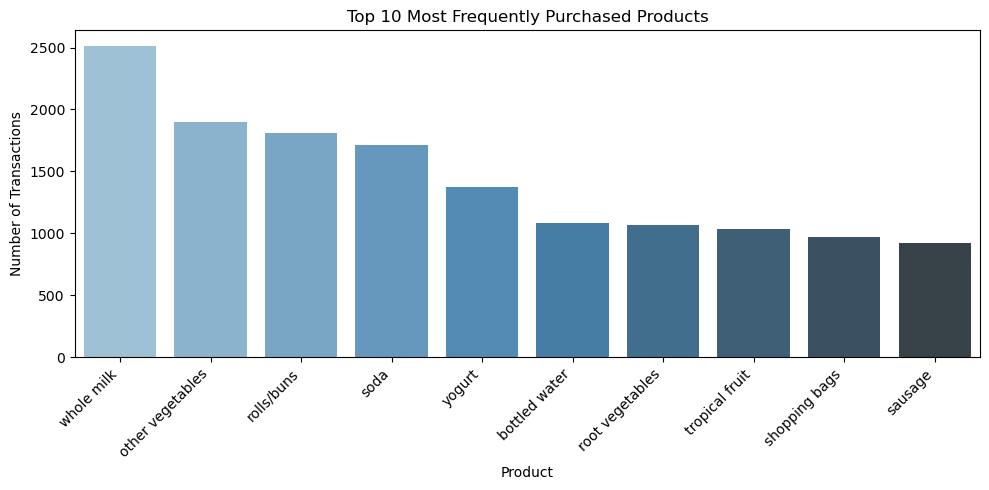

In [18]:
# Visualize the top 10 products

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_items,
    x="Product",
    y="Transactions",
    palette="Blues_d",
    hue="Product",
    legend=False
)

plt.title("Top 10 Most Frequently Purchased Products")
plt.xlabel("Product")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 📌Insight 1 — Most Frequently Purchased Products

Whole milk is the most frequently purchased product, appearing in 2,513 transactions (25.6% of all transactions), followed by other vegetables, rolls/buns, soda and yogurt.

**Business implication:**  
These high-volume products can be used as anchor products for cross-selling recommendations.

**Recommendation:**  
When customers purchase high-volume products such as whole milk, recommend complementary products based on the association rules.

## 4. Transaction Encoding

In [21]:
# Convert transactions into True/False format
te = TransactionEncoder()

transaction_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    transaction_array,
    columns=te.columns_
)

basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## 5. Apply the Apriori Algorithm

`min_support=0.01` means a product combination must appear in at least 1% of transactions.

`max_len=3` keeps the analysis practical by focusing on individual products, pairs and small 3-product bundles.

In [24]:
# Generate frequent itemsets
frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True,
    max_len=3
)

print("Number of frequent itemsets:", len(frequent_itemsets))

frequent_itemsets.head()

Number of frequent itemsets: 333


,support,itemsets
0,0.033452,(UHT-milk)
1,0.017692,(baking powder)
2,0.052466,(beef)
3,0.033249,(berries)
4,0.026029,(beverages)


In [26]:
# Sort frequent itemsets by support
frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(15)

,support,itemsets
86,0.255516,(whole milk)
55,0.193493,(other vegetables)
66,0.183935,(rolls/buns)
75,0.174377,(soda)
87,0.139502,(yogurt)
6,0.110524,(bottled water)
67,0.108998,(root vegetables)
81,0.104931,(tropical fruit)
73,0.098526,(shopping bags)
70,0.093950,(sausage)


## 6. Most Common Product Pairs

### Business Question 2: Which product combinations occur most often?

We focus on 2-product itemsets to identify practical cross-selling opportunities.

In [29]:
# Keep only 2-product combinations
pair_itemsets = frequent_itemsets[
    frequent_itemsets["itemsets"].apply(len) == 2
].copy()

# Convert support into approximate transaction count
pair_itemsets["support_count"] = (
    pair_itemsets["support"] * len(df)
).round().astype(int)

pair_itemsets.sort_values(
    "support",
    ascending=False
).head(10)

,support,itemsets,support_count
239,0.074835,"(whole milk, other vegetables)",736
267,0.056634,"(whole milk, rolls/buns)",557
300,0.056024,"(whole milk, yogurt)",551
274,0.048907,"(whole milk, root vegetables)",481
229,0.047382,"(root vegetables, other vegetables)",466
240,0.043416,"(yogurt, other vegetables)",427
228,0.042603,"(rolls/buns, other vegetables)",419
294,0.042298,"(whole milk, tropical fruit)",416
290,0.040061,"(whole milk, soda)",394
264,0.038332,"(soda, rolls/buns)",377


In [31]:
# Create readable product-pair names
top_pairs = pair_itemsets.sort_values(
    "support",
    ascending=False
).head(10).copy()

top_pairs["pair"] = top_pairs["itemsets"].apply(
    lambda x: " + ".join(sorted(list(x)))
)

top_pairs[["pair", "support_count", "support"]]

,pair,support_count,support
239,other vegetables + whole milk,736,0.074835
267,rolls/buns + whole milk,557,0.056634
300,whole milk + yogurt,551,0.056024
274,root vegetables + whole milk,481,0.048907
229,other vegetables + root vegetables,466,0.047382
240,other vegetables + yogurt,427,0.043416
228,other vegetables + rolls/buns,419,0.042603
294,tropical fruit + whole milk,416,0.042298
290,soda + whole milk,394,0.040061
264,rolls/buns + soda,377,0.038332


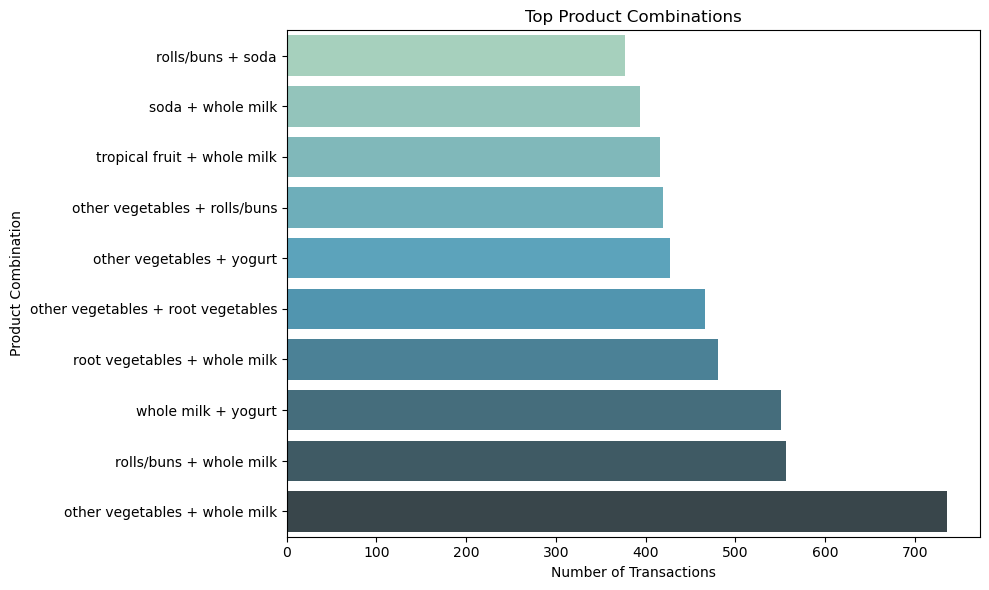

In [33]:
# Visualize top product combinations

plot_data = top_pairs.sort_values("support_count", ascending=True)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="support_count",
    y="pair",
    palette="GnBu_d",
    hue="pair",
    legend=False
)

plt.title("Top Product Combinations")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Combination")

plt.tight_layout()
plt.show()

### 📌 Insight 2 — Most Common Product Combinations

Other vegetables + whole milk is the most common product pair, occurring in 736 transactions (7.48% of all transactions).

Other frequently purchased combinations include rolls/buns + whole milk and whole milk + yogurt.

**Business implication:**  
These combinations represent strong opportunities for "Frequently Bought Together" recommendations.

**Recommendation:**  
Recommend one product when the customer adds its associated product to the cart and consider placing frequently associated products closer together.

## 7. Association Rules

### Business Question 3: Which product associations are strongest?

We use:
- **Support:** how often the combination appears.
- **Confidence:** how often the consequent is purchased when the antecedent is purchased.
- **Lift:** how much stronger the relationship is compared with random purchasing.

A lift greater than 1 indicates a positive association.

In [36]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)

rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules.head()

,antecedents,consequents,support,confidence,lift
0,(beef),(other vegetables),0.019725,0.375969,1.943066
1,(beef),(rolls/buns),0.013625,0.259690,1.411858
2,(beef),(root vegetables),0.017387,0.331395,3.040367
3,(beef),(whole milk),0.021251,0.405039,1.585180
4,(beef),(yogurt),0.011693,0.222868,1.597601


### 📌 Insight 3 — Strongest Product Associations

Beef → root vegetables is a particularly strong association, with 33.1% confidence and a lift of 3.04.

This indicates that customers purchasing beef are substantially more likely to purchase root vegetables than would be expected from their individual purchase frequencies.

**Business implication:**  
Lift-based recommendations can identify valuable relationships that may not simply be the most popular products.

**Recommendation:**  
When a customer adds beef to their cart, recommend root vegetables as a complementary product.

In [38]:
# Keep reasonably frequent and strong rules
strong_rules = rules[
    rules["support"] >= 0.01
].sort_values(
    ["lift", "confidence"],
    ascending=False
).copy()

# Create readable product names
strong_rules["antecedent"] = strong_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

strong_rules["consequent"] = strong_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

strong_rules[
    [
        "antecedent",
        "consequent",
        "support",
        "confidence",
        "lift"
    ]
].head(10)

,antecedent,consequent,support,confidence,lift
157,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
208,"other vegetables, yogurt",whipped/sour cream,0.010168,0.234192,3.267062
185,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780
2,beef,root vegetables,0.017387,0.331395,3.040367
158,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
184,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999
188,"other vegetables, whole milk",root vegetables,0.023183,0.309783,2.842082
190,root vegetables,"other vegetables, whole milk",0.023183,0.212687,2.842082
155,butter,"other vegetables, whole milk",0.011490,0.207339,2.770630
163,"curd, whole milk",yogurt,0.010066,0.385214,2.761356


## 8. Product Recommendation Function

### Business Question 4: If a customer buys Product A, what should we recommend?

The function below finds products associated with a selected product and ranks them by lift and confidence.

In [41]:
def recommend_products(product, rules_df, top_n=5):
    recommendations = rules_df[
        rules_df["antecedent"] == product
    ].sort_values(
        ["lift", "confidence"],
        ascending=False
    )

    return recommendations[
        ["antecedent", "consequent", "confidence", "lift"]
    ].head(top_n)

In [43]:
# Example: recommendations after buying whole milk
recommend_products("whole milk", strong_rules, 5)

,antecedent,consequent,confidence,lift
149,whole milk,yogurt,0.219260,1.571735
105,whole milk,other vegetables,0.292877,1.513634
125,whole milk,rolls/buns,0.221647,1.205032


In [45]:
# Example: recommendations after buying yogurt
recommend_products("yogurt", strong_rules, 5)

,antecedent,consequent,confidence,lift
143,yogurt,tropical fruit,0.209913,2.000475
107,yogurt,other vegetables,0.311224,1.608457
150,yogurt,whole milk,0.401603,1.571735
127,yogurt,rolls/buns,0.246356,1.339363


In [47]:
# Example: recommendations after buying root vegetables
recommend_products("root vegetables", strong_rules, 5)

,antecedent,consequent,confidence,lift
190,root vegetables,"other vegetables, whole milk",0.212687,2.842082
95,root vegetables,other vegetables,0.434701,2.246605
130,root vegetables,whole milk,0.448694,1.756031
131,root vegetables,yogurt,0.236940,1.698475
119,root vegetables,rolls/buns,0.222948,1.212101


### 📌 Insight 4 — Cross-Selling Recommendations

The association rules can be converted into product recommendations based on the customer's current basket.

For example:
- Beef → Root vegetables
- Yogurt → Tropical fruit
- Root vegetables → Other vegetables
- Whole milk → Yogurt

**Business recommendation:**  
Implement a "Customers who bought this also bought..." feature using high-confidence and high-lift rules.

## 9. 3-Product Bundle Opportunities

### Business Question 5: Which 3-product combinations can be used for bundle offers?

We identify the most frequently occurring 3-product combinations.

In [50]:
# Keep only 3-product itemsets
triple_itemsets = frequent_itemsets[
    frequent_itemsets["itemsets"].apply(len) == 3
].copy()

# Convert support into transaction count
triple_itemsets["support_count"] = (
    triple_itemsets["support"] * len(df)
).round().astype(int)

# Create readable bundle names
triple_itemsets["bundle"] = triple_itemsets["itemsets"].apply(
    lambda x: " + ".join(sorted(list(x)))
)

top_bundles = triple_itemsets.sort_values(
    "support",
    ascending=False
).head(10)

top_bundles[
    ["bundle", "support_count", "support"]
]

,bundle,support_count,support
316,other vegetables + root vegetables + whole milk,228,0.023183
324,other vegetables + whole milk + yogurt,219,0.022267
313,other vegetables + rolls/buns + whole milk,176,0.017895
320,other vegetables + tropical fruit + whole milk,168,0.017082
327,rolls/buns + whole milk + yogurt,153,0.015557
331,tropical fruit + whole milk + yogurt,149,0.015150
322,other vegetables + whipped/sour cream + whole ...,144,0.014642
329,root vegetables + whole milk + yogurt,143,0.014540
319,other vegetables + soda + whole milk,137,0.013930
310,other vegetables + pip fruit + whole milk,133,0.013523


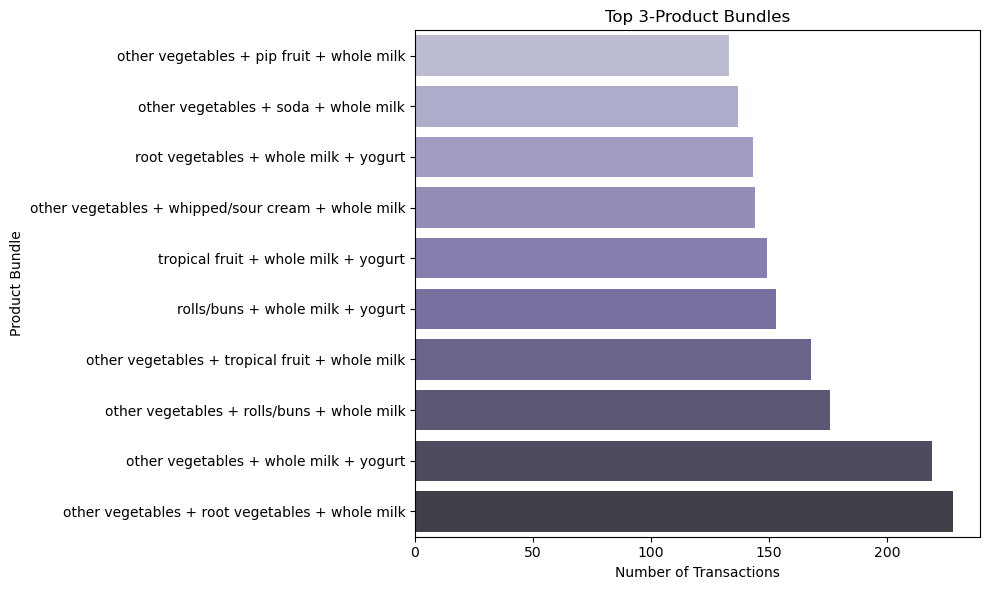

In [52]:
# Visualize top 3-product bundles

plot_data = top_bundles.sort_values("support_count", ascending=True)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="support_count",
    y="bundle",
    palette="Purples_d",
    hue="bundle",
    legend=False
)

plt.title("Top 3-Product Bundles")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Bundle")

plt.tight_layout()
plt.show()

### 📌 Insight 5 — Bundle Opportunities

Other vegetables + root vegetables + whole milk is the most common 3-product bundle, appearing in 228 transactions (2.32% of all transactions).

**Business implication:**  
Frequently purchased 3-product combinations can be tested as bundled offers.

**Recommendation:**  
Test bundle discounts or one-click bundle purchases for the strongest combinations and monitor their impact on average order value.


# Final Business Insights & Recommendations

## Key Insights

1. **Whole milk is the strongest anchor product**  
   Whole milk appears in 2,513 transactions, making it the most frequently purchased product.

2. **Other vegetables + whole milk is the strongest frequent pair**  
   The combination occurs in 736 transactions and represents 7.48% of all transactions.

3. **Beef → root vegetables is a strong cross-selling opportunity**  
   The rule has 33.1% confidence and 3.04 lift.

4. **Yogurt has several useful complementary relationships**  
   Yogurt shows strong associations with products such as whole milk and tropical fruit.

5. **Small product bundles can support promotional strategies**  
   Other vegetables + root vegetables + whole milk is the most common 3-product bundle.

## Business Recommendations

### 1. Personalized Cross-Selling
Use association rules to recommend complementary products when customers add an item to their cart.

### 2. Frequently Bought Together
Display frequently associated products together on product and cart pages.

### 3. Bundle Promotions
Test discounts or bundled offers using the strongest 3-product combinations.

### 4. Product Placement
Consider placing frequently associated products closer together in physical stores.

### 5. Measure Impact
Track:
- Average Order Value
- Items per Transaction
- Cross-Sell Conversion Rate
- Bundle Purchase Rate

# Conclusion

Market Basket Analysis identified meaningful relationships between products using transaction-level purchase data.

The analysis demonstrates how Apriori, frequent itemsets, support, confidence and lift can be translated into practical business strategies such as personalized recommendations, cross-selling, product placement and bundle promotions.